In [2]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
plt.style.use(['science','no-latex'])
import json

### Raw data processing

In [4]:
for num in range(1,4):
    tweets = []
    with open(f'{num}.json', 'r') as file:
        # One trainning trail
        for line in file:
            tweets.append(json.loads(line))
        index = []
        reward = []
        for tweet in tweets:
            index.append(tweet['num_env_steps_sampled'])
            reward.append(tweet['episode_reward_mean']) 
        index = np.array(index)
        reward = np.array(reward)
    np.save(f'Index_{num}.npy',index)
    np.save(f'Reward_{num}.npy',reward)
    print('Finished: Trail '+str(num))

Finished: Trail 1
Finished: Trail 2
Finished: Trail 3


### Mean and std

In [ ]:
index1 = np.load('Index_1.npy')
reward1 = np.load('Reward_1.npy')
index2 = np.load('Index_2.npy')
reward2 = np.load('Reward_2.npy')
index3 = np.load('Index_3.npy')
reward3 = np.load('Reward_3.npy')
reward = np.vstack((reward1,reward2, reward3))
print(reward.shape)


(3, 360)


In [8]:
mean_reward = np.average(reward, axis=0)
std_reward = np.std(reward, axis=0)
print(mean_reward.shape)

(360,)


### Result plot

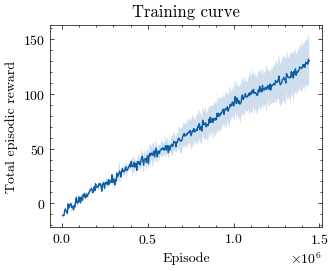

In [17]:
smooth = 1
max_reward = mean_reward + std_reward
min_reward = mean_reward - std_reward

plt.plot(index1[::smooth], mean_reward[::smooth])
plt.fill_between(index, max_reward, min_reward, alpha=0.2)
plt.title('Training curve')
plt.xlabel('Episode')
plt.ylabel('Total episodic reward')
plt.savefig('Training', dpi=300)
